<a href="https://colab.research.google.com/github/janbalangue/SQL-to-Python-Cloud-Notebook-Workflow/blob/master/sql_modern_workflows_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: SQL-to-Python Cloud Notebook Workflow

## Scenario: Support Operations Resolution Time

You are working as a junior data analyst for a software company's customer support operations team. The support operations manager asks:

> Can you help us understand which support ticket categories took the longest to resolve during the last quarter, and whether any team or category may need closer review?

Use the provided `support_operations.db` database and complete the notebook using the process **Identify -> Assemble -> Execute -> Verify**.


## Platform Setup

Place `support_operations.db` in the same folder as this notebook.

- **Google Colab:** upload the database file to the runtime, or mount Google Drive and update `db_path`.
- **Posit Cloud:** upload the database file to the project workspace.
- **SageMaker Studio Lab:** upload the database file to your home directory.


## Step 1: Clarify the Support Operations Question

Answer these questions in your own words:

- What question are you trying to answer?
- What does "took the longest to resolve" mean in this context?
- What data do you need?
- What output would be useful to the support operations manager?
- What checks will help you verify the result?
- What claim should you avoid making unless the data supports it?

### Planning Note

The business question is: which support ticket category and team combinations had the longest average resolution times among completed tickets created during Q1 2026, and which results may warrant closer review?

For this analysis, resolution time means the number of days between a ticket’s `created_date` and `resolved_date`. The analysis population includes tickets created from January 1, 2026 through March 31, 2026 that have a status of `Resolved` or `Closed` and a non-null `resolved_date`.

The required fields are available from the `tickets`, `ticket_categories`, and `teams` tables. From `tickets`, I need `ticket_id`, `status`, `created_date`, `resolved_date`, `category_id`, and `team_id`. The category and team tables provide the corresponding names.

The `ticket_events` table is not required because the `tickets` table already stores the creation date, resolution date, status, category, and team information needed to calculate and group resolution times. Event-level history is not necessary for the question being asked.

The expected output is one row for each category-and-team combination, including `total_completed_tickets` and average resolution time in days, sorted from the longest average resolution time to the shortest.

To verify the result, I will confirm the joins, ensure the population contains only tickets created during Q1 2026, confirm that completed tickets have a status of `Resolved` or `Closed` and a usable `resolved_date`, check group counts and missing or duplicate records, and investigate unusually long resolution times that could distort the averages.

The analysis can identify groups with longer observed resolution times, but it cannot by itself show that a team or category caused the delays or performed poorly.




## Step 2: Break Down the Workflow Plan

Address:

- Database connection
- Database inspection
- SQL query logic, including calculations, filters, grouping, and sorting
- DataFrame review
- Analysis approach
- Visualization
- Verification

### Workflow Plan

I will connect to the SQLite database in Colab and confirm that the database file exists and the connection succeeds. Next, I will inspect the available tables, columns, and relationships so the analysis uses the actual database schema. I will also confirm that the `ticket_events` table is not needed because the required creation, resolution, status, category, and team fields are already available from the `tickets` table and its related lookup tables.

I will then write a SQL query that joins the ticket, category, and team data, calculates resolution time in days from `created_date` to `resolved_date`, filters to completed tickets with a status of `Resolved` or `Closed` that were created during Q1 2026, requires a non-null `resolved_date`, groups the results by category and team, includes `total_completed_tickets`, and sorts the groups by average resolution time in descending order.

After loading the SQL results into a Pandas DataFrame, I will review the first rows, shape, column names, data types, missing values, duplicate records, descriptive statistics, and group sizes. I will analyze which category and team combinations have the longest average resolution times and consider whether small samples or unusual values affect the results.

I will create a chart comparing average resolution times in days across the relevant groups. Finally, I will verify the SQL joins, Q1 2026 `created_date` filter, completed-ticket status filter, resolution-time calculation, total completed-ticket counts, missing or duplicate values, and unusually long resolution times before drawing conclusions.



## Step 3: Connect to the SQLite Database


In [176]:
# Import the tools needed for this workflow.
# sqlite3 connects Python to the SQLite database.
# pandas loads SQL results into DataFrames.
# matplotlib creates the chart.
# pathlib checks that the database file exists before connecting.
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


### Optional Google Colab Drive Setup

If you are using Google Colab and your database is stored in Google Drive, uncomment and run the cell below before creating the database connection. Then update `db_path` to the full Drive path for your database file.


In [177]:
# Google Colab only: uncomment and run this cell if your database is stored in Drive.
# This sets db_path to your Drive location. The connection cell below will use it.
from google.colab import drive
drive.mount('/content/drive')
db_path = "/content/drive/MyDrive/support_operations.db"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Create the SQLite Connection


In [178]:
# If you set db_path in the optional Colab cell above, skip or remove this line.
# Otherwise, update this path to match your platform and file location.
# db_path = "support_operations.db"

if not Path(db_path).exists():
    raise FileNotFoundError(
        f"Could not find {db_path}. Upload the database file to this notebook's working directory, "
        "or update db_path to the correct location."
    )

conn = sqlite3.connect(db_path)
print("Database connection created.")


Database connection created.


## Step 4: Inspect the Database Structure

List the database tables, then inspect the relevant tables before writing your main query.


In [179]:
# Inspect

tables = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""").fetchall()

print("Tables:")
for table in tables:
    print(table[0])

for table_name, in tables:
    print(f"\n--- {table_name} ---")

    columns = conn.execute(
        f"PRAGMA table_info('{table_name}');"
    ).fetchall()

    for column in columns:
        print(column)

Tables:
agents
customers
teams
ticket_categories
ticket_events
tickets

--- agents ---
(0, 'agent_id', 'INTEGER', 0, None, 1)
(1, 'agent_name', 'TEXT', 1, None, 0)
(2, 'team_id', 'INTEGER', 1, None, 0)
(3, 'role_level', 'TEXT', 1, None, 0)
(4, 'hire_date', 'TEXT', 1, None, 0)
(5, 'is_active', 'INTEGER', 1, '1', 0)

--- customers ---
(0, 'customer_id', 'INTEGER', 0, None, 1)
(1, 'customer_segment', 'TEXT', 1, None, 0)
(2, 'account_tier', 'TEXT', 1, None, 0)
(3, 'industry', 'TEXT', 1, None, 0)

--- teams ---
(0, 'team_id', 'INTEGER', 0, None, 1)
(1, 'team_name', 'TEXT', 1, None, 0)
(2, 'team_region', 'TEXT', 1, None, 0)
(3, 'manager_name', 'TEXT', 1, None, 0)

--- ticket_categories ---
(0, 'category_id', 'INTEGER', 0, None, 1)
(1, 'category_name', 'TEXT', 1, None, 0)
(2, 'category_group', 'TEXT', 1, None, 0)
(3, 'standard_resolution_days', 'REAL', 1, None, 0)

--- ticket_events ---
(0, 'event_id', 'INTEGER', 0, None, 1)
(1, 'ticket_id', 'INTEGER', 1, None, 0)
(2, 'event_type', 'TEXT', 1,

## Step 5: Plan Your SQL Query Before Running It

Complete this checklist using the table and column names you found.

| Query Need | Actual Table or Column Name |
|---|---|
| Main ticket table | `tickets` |
| Ticket ID column | `ticket_id` |
| Ticket status column | `status` |
| Created date column | `created_date` |
| Resolved date column | `resolved_date` |
| Category table, if separate | `ticket_categories` |
| Category ID column | `category_id` |
| Category name column | `category_name` |
| Team table, if separate | `teams` |
| Team ID column | `team_id` |
| Team name column | `team_name` |
| Date range for the last quarter | Use `2026-01-01` through `2026-03-31` for Q1 2026 |

Then answer:

- Which fields will you use to calculate resolution time?

I will use `created_date` and `resolved_date` to calculate resolution time. Resolution time is the number of days between when a ticket was created and when it was resolved.

- Which field will you use to filter resolved tickets?

I will use `status IN ('Resolved', 'Closed')` to identify completed tickets, require a non-null `resolved_date`, and use `created_date` to restrict the population to tickets created during Q1 2026.

- Which field or fields will you group by?

I will group by `category_name` and `team_name`.

- Which field will you sort by?

I will sort by `avg_resolution_days` in descending order so the category-team combinations with the longest average resolution times appear first.

- What could go wrong if you choose the wrong date column or join column?

Using the wrong date column could select the wrong population. For this analysis, Q1 2026 is defined by `created_date`; filtering on `resolved_date` instead would answer a different question. Using the wrong join column could mismatch tickets with categories or teams, create duplicate or missing records, and make counts or average resolution times incorrect.


## Step 6: Query Support Ticket Resolution Time with SQL

Write and run a query that calculates average resolution time by ticket category, team, or both.

Use this date range: `2026-01-01` through `2026-03-31`.


In [180]:
# Query

resolution_df = pd.read_sql_query("""
SELECT
    c.category_name,
    tm.team_name,
    COUNT(t.ticket_id) AS total_completed_tickets,
    ROUND(
        AVG(
            julianday(t.resolved_date) - julianday(t.created_date)
        ),
        2
    ) AS avg_resolution_days
FROM tickets AS t
JOIN ticket_categories AS c
    ON t.category_id = c.category_id
JOIN teams AS tm
    ON t.team_id = tm.team_id
WHERE t.status IN ('Resolved', 'Closed')
  AND t.created_date >= '2026-01-01'
  AND t.created_date < '2026-04-01'
  AND t.resolved_date IS NOT NULL
GROUP BY
    c.category_name,
    tm.team_name
ORDER BY avg_resolution_days DESC;
""", conn)

display(resolution_df)

,category_name,team_name,total_completed_tickets,avg_resolution_days
0,API Integration,Enterprise Support,9,17.56
1,Security Review,Enterprise Support,1,14.00
2,Security Review,Security Support,6,12.67
3,Feature Request,Enterprise Support,10,10.40
4,Feature Request,Product Support,10,9.80
5,Performance Issue,Product Support,12,7.42
6,API Integration,Platform Support,7,6.57
7,Bug Report,Product Support,12,5.67
8,Bug Report,Enterprise Support,12,5.50
9,Performance Issue,Platform Support,8,5.25


## Step 7: Load and Review Results in Pandas

Run these checks after `resolution_df` has been created.


In [181]:
# Load and review

display(resolution_df.head())

print("Shape:", resolution_df.shape)

resolution_df.info()

display(resolution_df.isna().sum())

print("Duplicate rows:", resolution_df.duplicated().sum())

display(
    resolution_df[
        ["total_completed_tickets", "avg_resolution_days"]
    ].describe()
)

,category_name,team_name,total_completed_tickets,avg_resolution_days
0,API Integration,Enterprise Support,9,17.56
1,Security Review,Enterprise Support,1,14.00
2,Security Review,Security Support,6,12.67
3,Feature Request,Enterprise Support,10,10.40
4,Feature Request,Product Support,10,9.80


Shape: (18, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   category_name            18 non-null     object 
 1   team_name                18 non-null     object 
 2   total_completed_tickets  18 non-null     int64  
 3   avg_resolution_days      18 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 708.0+ bytes


,0
category_name,0
team_name,0
total_completed_tickets,0
avg_resolution_days,0


Duplicate rows: 0


,total_completed_tickets,avg_resolution_days
count,18.00000,18.000000
mean,9.50000,6.385556
std,3.29438,4.773785
min,1.00000,0.830000
25%,8.25000,2.980000
50%,10.00000,5.375000
75%,12.00000,9.205000
max,14.00000,17.560000


## Step 8: Analyze the Results

Identify the category/team combinations with the longest average resolution time.


In [182]:
# Analyze
longest_resolution = resolution_df.sort_values(
    by="avg_resolution_days",
    ascending=False
)

display(
    longest_resolution[
        [
            "category_name",
            "team_name",
            "total_completed_tickets",
            "avg_resolution_days"
        ]
    ].head()
)

,category_name,team_name,total_completed_tickets,avg_resolution_days
0,API Integration,Enterprise Support,9,17.56
1,Security Review,Enterprise Support,1,14.00
2,Security Review,Security Support,6,12.67
3,Feature Request,Enterprise Support,10,10.40
4,Feature Request,Product Support,10,9.80


### Analysis Notes

Answer:

- Which category or category-team combination had the longest average resolution time?
- How many resolved tickets were included for that category or team?
- Is the ticket count large enough to treat the pattern as meaningful?
- What additional information would help explain the result?

The API Integration / Enterprise Support combination had the longest average resolution time at 17.56 days. This result was based on 9 completed tickets (`Resolved` or `Closed`) that were created during Q1 2026.

Because the ticket count is relatively small, the result should be interpreted cautiously. Nine tickets are enough to identify this category-team combination as a candidate for closer review, but the sample is not large enough by itself to establish a consistent performance pattern. A few unusually long tickets could substantially affect the average.

Additional information such as individual resolution times, median resolution time, ticket priority, outliers, staffing levels, reassignment history, and external dependencies would help explain why this category-team combination had the longest observed average resolution time.



## Step 9: Visualize the Results

Create a chart that clearly communicates the main comparison.


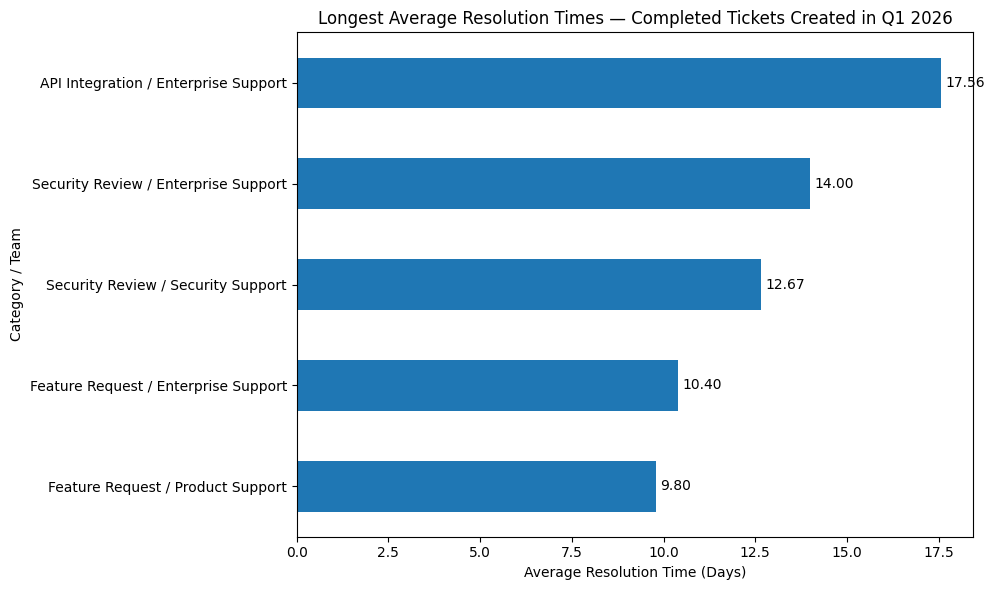

In [183]:
# Chart

chart_df = resolution_df.copy()

chart_df["category_team"] = (
    chart_df["category_name"] + " / " + chart_df["team_name"]
)

top_5 = (
    chart_df
    .sort_values("avg_resolution_days", ascending=False)
    .head(5)
    .sort_values("avg_resolution_days")
)

ax = top_5.plot(
    kind="barh",
    x="category_team",
    y="avg_resolution_days",
    legend=False,
    figsize=(10, 6)
)

ax.set_title(
    "Longest Average Resolution Times — Completed Tickets Created in Q1 2026"
)
ax.set_xlabel("Average Resolution Time (Days)")
ax.set_ylabel("Category / Team")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## Step 10: Evaluate and Verify the Output

Verify that the workflow produced a trustworthy result.


In [184]:
# Verify

# Verify the number of completed tickets created during Q1 2026
q1_count = pd.read_sql_query("""
SELECT COUNT(*) AS total_completed_tickets
FROM tickets
WHERE status IN ('Resolved', 'Closed')
  AND created_date >= '2026-01-01'
  AND created_date < '2026-04-01'
  AND resolved_date IS NOT NULL;
""", conn)

display(q1_count)

# Inspect the category/team combination with the highest average
verification_df = pd.read_sql_query("""
SELECT
    t.ticket_id,
    t.status,
    t.created_date,
    t.resolved_date,
    ROUND(
        julianday(t.resolved_date) - julianday(t.created_date),
        2
    ) AS resolution_days
FROM tickets AS t
JOIN ticket_categories AS c
    ON t.category_id = c.category_id
JOIN teams AS tm
    ON t.team_id = tm.team_id
WHERE t.status IN ('Resolved', 'Closed')
  AND t.created_date >= '2026-01-01'
  AND t.created_date < '2026-04-01'
  AND t.resolved_date IS NOT NULL
  AND c.category_name = 'API Integration'
  AND tm.team_name = 'Enterprise Support'
ORDER BY resolution_days;
""", conn)

display(verification_df)

print("Ticket count:", len(verification_df))
print("Mean:", verification_df["resolution_days"].mean())
print("Median:", verification_df["resolution_days"].median())
print(
    "Duplicate ticket IDs:",
    verification_df["ticket_id"].duplicated().sum()
)
print(
    "Missing values:",
    verification_df.isna().sum().sum()
)

,total_completed_tickets
0,171


,ticket_id,status,created_date,resolved_date,resolution_days
0,314,Closed,2026-02-08,2026-02-11,3.0
1,138,Resolved,2026-01-19,2026-01-25,6.0
2,46,Closed,2026-01-01,2026-01-10,9.0
3,115,Resolved,2026-01-26,2026-02-04,9.0
4,203,Resolved,2026-01-31,2026-02-13,13.0
5,286,Resolved,2026-02-23,2026-03-08,13.0
6,288,Resolved,2026-03-26,2026-04-08,13.0
7,124,Resolved,2026-01-24,2026-02-10,17.0
8,452,Resolved,2026-01-04,2026-03-20,75.0


Ticket count: 9
Mean: 17.555555555555557
Median: 13.0
Duplicate ticket IDs: 0
Missing values: 0


### Verification Notes

Address:

- Did the query use the actual table and column names?
- Did the query use the correct joins?
- Did the date filter match Q1 2026?
- Did the query include only resolved tickets?
- Did the resolution-time calculation make sense?
- Were there missing values, duplicates, small sample sizes, or unusual values?
- Did the chart match the DataFrame?
- Did your written conclusion stay within what the data supports?

The query used the actual database tables and columns and joined `tickets` to `ticket_categories` by `category_id` and to `teams` by `team_id`. The Q1 2026 population was correctly defined using tickets created from January 1 through March 31, 2026.

The analysis included completed tickets with a status of either `Resolved` or `Closed` and required a non-null `resolved_date`. Resolution time was calculated as the number of days between `created_date` and `resolved_date`, which matched the required metric.

The DataFrame checks did not identify unexpected missing values or duplicate rows. Some category-team combinations had small sample sizes, so their averages should be interpreted cautiously. API Integration / Enterprise Support had the highest average resolution time at 17.56 days across 9 completed tickets, which is a relatively small group and may be sensitive to unusually long individual cases.

The chart was created from `resolution_df` and reflected the same category-team groups and average resolution times in days. The written conclusion stayed within what the data supports by identifying groups for closer review without claiming that a team or category caused the longer resolution times.



## Step 11: Write a Supported Final Explanation

Include:

- The original question
- The main finding
- Evidence from your SQL-to-Python workflow
- One limitation or assumption
- One recommended next step for review

### Final Explanation

The original question was which support ticket category-team combinations had the longest average resolution times among completed tickets created during Q1 2026.

The main finding was that API Integration / Enterprise Support had the longest average resolution time at 17.56 days. The SQL query used the actual database tables and join keys, included tickets with a status of `Resolved` or `Closed`, filtered to tickets created from January 1 through March 31, 2026, and calculated resolution time from `created_date` to `resolved_date`. The grouped results were loaded into Pandas for review and visualization. The analysis included 171 completed tickets overall, and the leading category-team combination contained 9 tickets.

One limitation is that the leading group contained only 9 completed tickets, so its average may be sensitive to unusually long individual cases and should not by itself be treated as evidence of poor team performance. A useful next step would be to review the individual API Integration / Enterprise Support tickets, including their median resolution time, priority, reassignment history, and any unusually long cases, to better understand the observed result.



## Step 12: Reflect on the Workflow

Answer:

- What was the most important step in making your result trustworthy?
- What issue or challenge did you need to check, debug, or refine?
- How did Identify → Assemble → Execute → Verify help you complete the workflow?
- How could this workflow be applied in another context?
- What would you improve if you repeated this analysis?
- What cloud constraint did you encounter, and how did you manage it?

### Reflection

The most important step was verifying the query against the actual database structure and checking the results after execution. I had to refine the workflow by confirming the correct table and column names, fixing the database file path in Colab, defining Q1 2026 using `created_date`, and confirming that completed tickets included both `Resolved` and `Closed` statuses.

**Identify → Assemble → Execute → Verify** helped by separating the problem into clear stages: define the question, build the query from the real schema, run it, and then confirm that the output made sense. This same workflow could be applied to other analyses such as customer support trends, sales performance, or healthcare operations.

If I repeated the analysis, I would add a median or another outlier-resistant measure alongside the mean so unusually long tickets are easier to evaluate. The main cloud constraint was that the database was initially in Google Drive’s “Shared with me” area rather than the expected My Drive path, so I resolved it by making the file accessible from the mounted Drive location used by Colab.


## Close the Database Connection


In [185]:
conn.close()
print("Database connection closed.")


Database connection closed.
